# Importing the Data
### CelebA Dataset 

We will be utilizing the CelebA dataset for this exploration \
Pixels values will be normalized from [0,255] -> [-1, 1] \
This is done to work in conjunction with the Generator's tanh activation output \

In [8]:
import torchvision.transforms as transforms

# mean and std of channels
mean = [0.5, 0.5, 0.5] # [R,G,B]
std = [0.5, 0.5, 0.5] # [R,G,B]

transform = transforms.Compose([
    transforms.CenterCrop((178, 178)),
    transforms.Resize((64, 64)),
    transforms.ToTensor(), # pixel values go from [0,255] to [0,1]
    transforms.Normalize(
        mean=mean,
        std=std
    ) # pixel values go from [0,1] to [-1,1]
])

In [ ]:
from torchvision.datasets import CelebA
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_dataset = CelebA(root='../data', split='train', transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


# Defining the Model

### Generator : 
Input: a latent z of dimension noise_dim (assume gaussian distribution) \
Output : A proposed image

### Discriminator
Input: a proposed image, namely the output G(z) \
Output : A binary classification label 
* '1' : The discriminator predicts that the image comes from distribution pdata (image is part of training set) 
* '0' : The dicrimimator predicts that the image comes from distribution pG (image was generated by Generator) 

### Goal 
The minimax game has achieved optimality when: 

$pG(x) = pData(x)$ (Optimal generator for optimal D) \
$DG(x) = \frac{pdata(x)}{pdata(x) + pG(x)} = 0.5$ (Discriminator is guessing)

In [10]:
import torch.nn as nn 

LATENT_DIM = 100

class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, img_height=64, img_width=64, img_channels=3):
        super().__init__()
        self.latent_dim = latent_dim
        self.model = nn.Sequential(
            nn.Linear(self.latent_dim, 256), 
            nn.BatchNorm1d(256),
            nn.ReLU(), 

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            # Flatten to image dimensions
            # Tanh b/c pixel values are normalized between -1 and 1
            nn.Linear(512, img_height * img_width * img_channels),
            nn.Tanh(), # values \in [-1, 1]

            # [B, H * W * C] -> [B, C, H, W]
            nn.Unflatten(-1, (img_channels, img_height, img_width))
        )

    def forward(self, z):
        x = self.model(z)
        return x

In [11]:
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, img_height=64, img_width=64, img_channels=3):
        super().__init__()

        # P(Y=1|x) = D(x) = sigmoid(f(x))
        # we will use BCEWithLogitsLoss below, because it is more numerically stable than using a plain Sigmoid followed by a BCELoss
        self.model = nn.Sequential(
            nn.Flatten(start_dim=1), 

            nn.Linear(img_height * img_width * img_channels, 512), 
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 1),
        )

    def forward(self, x):
        y = self.model(x)
        return y

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt

def generate_and_save_images(model, epoch, noise):
    Path("../data/vanilla-gan").mkdir(parents=True, exist_ok=True)

    model.eval()
    with torch.no_grad():
        fake_images = model(noise).cpu() # [-1, 1]
        fake_images = (fake_images.clamp(-1, 1) + 1) / 2 # [0, 1]

        fig = plt.figure(figsize = (4,4))
        for i in range(fake_images.size(0)):
            plt.subplot(4, 4, i + 1)

            image = fake_images[i].permute(1,2,0) # [C, H, W] -> [H, W, C]
            plt.imshow(image)
            plt.axis('off')

        plt.savefig(f"../data/vanilla-gan//image_at_epoch_{epoch+1:04d}.png")
        plt.show()
        
    model.train()

In [13]:
import torch

def train_gan(generator,
              discriminator,
              generator_optimizer, 
              discriminator_optimizer, 
              train_loader, 
              device, 
              latent_dim=100, 
              num_epochs=50, 
              loss_function=nn.BCEWithLogitsLoss(), 
              fixed_noise=None,
              ):
    for epoch in range(num_epochs):
        for i, data in enumerate(train_loader):
            real_images, _ = data
            real_images = real_images.to(device)

            # ------  train discriminator on real data ------
            discriminator_optimizer.zero_grad()                        # zero out the gradients from the previous batch
            real_labels = torch.ones(real_images.size(0), 1, device=device) # (B, 1) -> '1' for each image in the batch
            real_outputs = discriminator(real_images)
            real_loss = loss_function(real_outputs, real_labels)
            real_loss.backward()                                       # computes weight updates for real images

            # ------ train discriminator on fake data ------
            z = torch.randn(real_images.size(0), latent_dim, device=device)
            fake_images = generator(z)
            fake_labels = torch.zeros(real_images.size(0), 1, device=device) # (B, 1) -> '0' for every img in the batch
            fake_outputs = discriminator(fake_images.detach())          # detach does not propagate gradients back through G
            fake_loss = loss_function(fake_outputs, fake_labels)
            fake_loss.backward()
            discriminator_optimizer.step()

            # ------ train the generator on the real data ------
            generator_optimizer.zero_grad()
            fake_labels = torch.ones(real_images.size(0), 1, device=device)  # # (B, 1) -> '1' for each image in the batch
            fake_outputs = discriminator(fake_images)                   # D(G(z))
            gen_loss = loss_function(fake_outputs, fake_labels)         # BCE(D(G(z)), 1) : B/C generator ideally wants to fool discriminator
            gen_loss.backward()
            generator_optimizer.step()

            if i % 100 == 0:
                print(f"Epoch [{epoch+1} / {num_epochs}], Step [{i + 1} / {len(train_loader)}] ,"
                      f"Discriminator Loss : {real_loss.item() + fake_loss.item():.4f}"
                      f"Generator Loss : {gen_loss.item():.4f}")
                
        if fixed_noise is not None:
            generate_and_save_images(generator, epoch, fixed_noise)


Epoch [1 / 50], Step [1 / 2544] ,Discriminator Loss : 1.4453Generator Loss : 1.0140
Epoch [1 / 50], Step [101 / 2544] ,Discriminator Loss : 1.3542Generator Loss : 0.7017
Epoch [1 / 50], Step [201 / 2544] ,Discriminator Loss : 1.3438Generator Loss : 0.7537
Epoch [1 / 50], Step [301 / 2544] ,Discriminator Loss : 1.2016Generator Loss : 0.8391
Epoch [1 / 50], Step [401 / 2544] ,Discriminator Loss : 1.1069Generator Loss : 1.0287
Epoch [1 / 50], Step [501 / 2544] ,Discriminator Loss : 1.1198Generator Loss : 1.0961
Epoch [1 / 50], Step [601 / 2544] ,Discriminator Loss : 0.9819Generator Loss : 1.2247
Epoch [1 / 50], Step [701 / 2544] ,Discriminator Loss : 1.3602Generator Loss : 1.1999
Epoch [1 / 50], Step [801 / 2544] ,Discriminator Loss : 0.9705Generator Loss : 1.5503
Epoch [1 / 50], Step [901 / 2544] ,Discriminator Loss : 1.0215Generator Loss : 1.6772
Epoch [1 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.4915Generator Loss : 1.8016
Epoch [1 / 50], Step [1101 / 2544] ,Discriminator Loss 

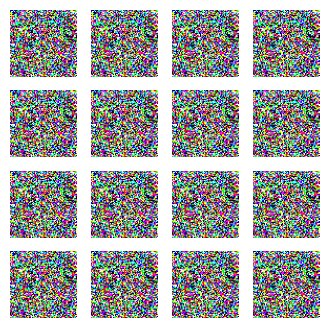

Epoch [2 / 50], Step [1 / 2544] ,Discriminator Loss : 0.3464Generator Loss : 3.0809
Epoch [2 / 50], Step [101 / 2544] ,Discriminator Loss : 0.4256Generator Loss : 3.5645
Epoch [2 / 50], Step [201 / 2544] ,Discriminator Loss : 0.4999Generator Loss : 2.2356
Epoch [2 / 50], Step [301 / 2544] ,Discriminator Loss : 0.1570Generator Loss : 3.1366
Epoch [2 / 50], Step [401 / 2544] ,Discriminator Loss : 0.5341Generator Loss : 2.9686
Epoch [2 / 50], Step [501 / 2544] ,Discriminator Loss : 0.2125Generator Loss : 3.3295
Epoch [2 / 50], Step [601 / 2544] ,Discriminator Loss : 0.3784Generator Loss : 2.4992
Epoch [2 / 50], Step [701 / 2544] ,Discriminator Loss : 0.2035Generator Loss : 3.2904
Epoch [2 / 50], Step [801 / 2544] ,Discriminator Loss : 0.1645Generator Loss : 4.0639
Epoch [2 / 50], Step [901 / 2544] ,Discriminator Loss : 0.3427Generator Loss : 3.8196
Epoch [2 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.2817Generator Loss : 3.7029
Epoch [2 / 50], Step [1101 / 2544] ,Discriminator Loss 

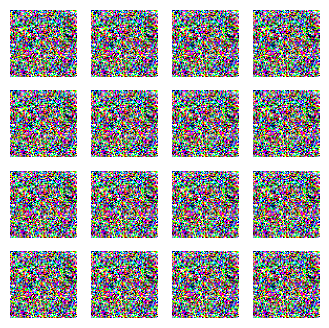

Epoch [3 / 50], Step [1 / 2544] ,Discriminator Loss : 0.2881Generator Loss : 3.6940
Epoch [3 / 50], Step [101 / 2544] ,Discriminator Loss : 0.1173Generator Loss : 2.9573
Epoch [3 / 50], Step [201 / 2544] ,Discriminator Loss : 0.5728Generator Loss : 2.6678
Epoch [3 / 50], Step [301 / 2544] ,Discriminator Loss : 0.2740Generator Loss : 4.2028
Epoch [3 / 50], Step [401 / 2544] ,Discriminator Loss : 0.2818Generator Loss : 3.8725
Epoch [3 / 50], Step [501 / 2544] ,Discriminator Loss : 0.2938Generator Loss : 4.0052
Epoch [3 / 50], Step [601 / 2544] ,Discriminator Loss : 0.9788Generator Loss : 4.1475
Epoch [3 / 50], Step [701 / 2544] ,Discriminator Loss : 0.1602Generator Loss : 3.0500
Epoch [3 / 50], Step [801 / 2544] ,Discriminator Loss : 0.2816Generator Loss : 4.7313
Epoch [3 / 50], Step [901 / 2544] ,Discriminator Loss : 0.1989Generator Loss : 3.2427
Epoch [3 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.2408Generator Loss : 1.9578
Epoch [3 / 50], Step [1101 / 2544] ,Discriminator Loss 

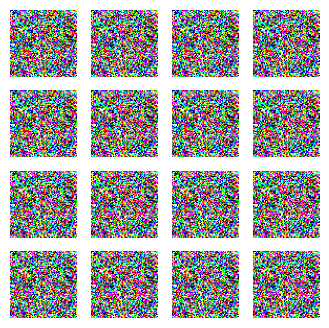

Epoch [4 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0561Generator Loss : 4.0774
Epoch [4 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0587Generator Loss : 5.4584
Epoch [4 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0546Generator Loss : 3.8087
Epoch [4 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0549Generator Loss : 3.3833
Epoch [4 / 50], Step [401 / 2544] ,Discriminator Loss : 0.1002Generator Loss : 4.4976
Epoch [4 / 50], Step [501 / 2544] ,Discriminator Loss : 0.4006Generator Loss : 4.0977
Epoch [4 / 50], Step [601 / 2544] ,Discriminator Loss : 0.1322Generator Loss : 3.4737
Epoch [4 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0681Generator Loss : 3.3627
Epoch [4 / 50], Step [801 / 2544] ,Discriminator Loss : 0.2302Generator Loss : 5.7728
Epoch [4 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0386Generator Loss : 4.3712
Epoch [4 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.1305Generator Loss : 3.0497
Epoch [4 / 50], Step [1101 / 2544] ,Discriminator Loss 

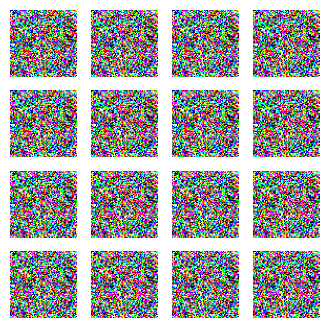

Epoch [5 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0574Generator Loss : 3.6192
Epoch [5 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0556Generator Loss : 4.1091
Epoch [5 / 50], Step [201 / 2544] ,Discriminator Loss : 0.2336Generator Loss : 4.1708
Epoch [5 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0212Generator Loss : 4.5417
Epoch [5 / 50], Step [401 / 2544] ,Discriminator Loss : 0.7864Generator Loss : 4.3038
Epoch [5 / 50], Step [501 / 2544] ,Discriminator Loss : 0.1845Generator Loss : 4.3238
Epoch [5 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0450Generator Loss : 4.2136
Epoch [5 / 50], Step [701 / 2544] ,Discriminator Loss : 0.1175Generator Loss : 5.7352
Epoch [5 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0239Generator Loss : 4.8740
Epoch [5 / 50], Step [901 / 2544] ,Discriminator Loss : 0.2389Generator Loss : 5.5051
Epoch [5 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0263Generator Loss : 3.9086
Epoch [5 / 50], Step [1101 / 2544] ,Discriminator Loss 

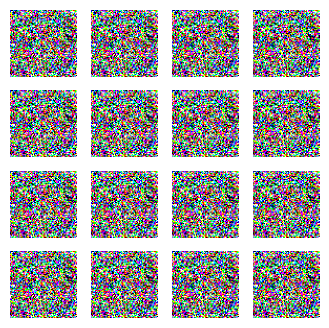

Epoch [6 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0832Generator Loss : 4.4342
Epoch [6 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0259Generator Loss : 4.8812
Epoch [6 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0376Generator Loss : 4.3429
Epoch [6 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0637Generator Loss : 4.7337
Epoch [6 / 50], Step [401 / 2544] ,Discriminator Loss : 0.0254Generator Loss : 5.4103
Epoch [6 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0445Generator Loss : 3.4645
Epoch [6 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0464Generator Loss : 6.4704
Epoch [6 / 50], Step [701 / 2544] ,Discriminator Loss : 0.2025Generator Loss : 5.5546
Epoch [6 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0354Generator Loss : 4.0059
Epoch [6 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0393Generator Loss : 3.8542
Epoch [6 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0216Generator Loss : 4.5981
Epoch [6 / 50], Step [1101 / 2544] ,Discriminator Loss 

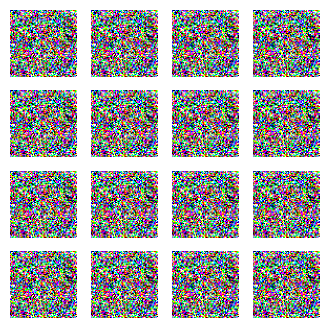

Epoch [7 / 50], Step [1 / 2544] ,Discriminator Loss : 0.0362Generator Loss : 4.7766
Epoch [7 / 50], Step [101 / 2544] ,Discriminator Loss : 0.0411Generator Loss : 4.7224
Epoch [7 / 50], Step [201 / 2544] ,Discriminator Loss : 0.0367Generator Loss : 5.2908
Epoch [7 / 50], Step [301 / 2544] ,Discriminator Loss : 0.0117Generator Loss : 5.2169
Epoch [7 / 50], Step [401 / 2544] ,Discriminator Loss : 0.3103Generator Loss : 4.9103
Epoch [7 / 50], Step [501 / 2544] ,Discriminator Loss : 0.0424Generator Loss : 5.9445
Epoch [7 / 50], Step [601 / 2544] ,Discriminator Loss : 0.0353Generator Loss : 3.6504
Epoch [7 / 50], Step [701 / 2544] ,Discriminator Loss : 0.0884Generator Loss : 5.9693
Epoch [7 / 50], Step [801 / 2544] ,Discriminator Loss : 0.0826Generator Loss : 4.7924
Epoch [7 / 50], Step [901 / 2544] ,Discriminator Loss : 0.0194Generator Loss : 4.4039
Epoch [7 / 50], Step [1001 / 2544] ,Discriminator Loss : 0.0169Generator Loss : 4.6894
Epoch [7 / 50], Step [1101 / 2544] ,Discriminator Loss 

KeyboardInterrupt: 

In [14]:
NUM_EPOCHS = 50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator = Generator(latent_dim=LATENT_DIM).to(device)
discriminator = Discriminator().to(device)

generator_optimizer = torch.optim.AdamW(generator.parameters())
discriminator_optimizer = torch.optim.AdamW(discriminator.parameters())

fixed_noise = torch.randn(16, LATENT_DIM, device=device)

train_gan(generator,
        discriminator,
        generator_optimizer, 
        discriminator_optimizer, 
        train_loader, 
        device, 
        latent_dim=100, 
        num_epochs=50, 
        loss_function=nn.BCEWithLogitsLoss(), 
        fixed_noise=fixed_noise
        )